# Test các cấu hình Deterministic trên GPU RTX5090

**GPU Target**: RTX5090  
**Compute Capability**: 12.0 (Blackwell architecture)  
**TF32 Support**: ✅ Hỗ trợ

**Mục tiêu**: Test các phương pháp khắc phục vấn đề reproducibility trên GPU RTX5090:
1. Tắt TF32
2. Tắt AMP (Automatic Mixed Precision)
3. Tắt cuDNN benchmark
4. Đặt num_workers = 0
5. Bật deterministic algorithms

**Kỳ vọng**: Với các cấu hình này, kết quả sẽ gần giống nhau hơn (nhưng vẫn có thể khác do floating-point precision).


## 1. Kiểm tra GPU và thiết lập môi trường


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
import os
import functools

# Kiểm tra GPU
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_capability = torch.cuda.get_device_capability(0)
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"GPU: {gpu_name}")
    print(f"GPU Compute Capability: {gpu_capability}")
    
    # Kiểm tra TF32 support (RTX5090 hỗ trợ)
    print(f"\nTF32 enabled (cuDNN): {torch.backends.cudnn.allow_tf32}")
    if hasattr(torch.backends, 'cublas'):
        print(f"TF32 enabled (cuBLAS): {torch.backends.cublas.allow_tf32}")
    else:
        print("TF32 enabled (cuBLAS): N/A (không hỗ trợ trong phiên bản PyTorch này)")
    
    # Xác nhận GPU
    if "RTX 5090" not in gpu_name.upper() and "RTX5090" not in gpu_name.upper() and "5090" not in gpu_name:
        print(f"\n⚠️  CẢNH BÁO: GPU hiện tại ({gpu_name}) không phải RTX5090!")
        print("   Notebook này được thiết kế cho NVIDIA GeForce RTX 5090.")
        print("   Vẫn tiếp tục nhưng kết quả có thể khác.")
    else:
        print(f"\n✓ Đã xác nhận: GPU RTX5090")
else:
    print("❌ Không tìm thấy CUDA GPU!")


PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8
cuDNN version: 91002
GPU: NVIDIA GeForce RTX 5090
GPU Compute Capability: (12, 0)

TF32 enabled (cuDNN): True
TF32 enabled (cuBLAS): N/A (không hỗ trợ trong phiên bản PyTorch này)

✓ Đã xác nhận: GPU RTX5090


## 2. Định nghĩa các hàm helper


In [12]:
def _worker_init_fn(worker_id, seed_val=42):
    """Worker init function cho DataLoader (phải là top-level function để pickle được)"""
    np.random.seed(seed_val + worker_id)
def set_seed(seed=42, deterministic=False):
    """Thiết lập seed với tùy chọn deterministic mode"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        # Lưu ý: use_deterministic_algorithms có thể làm chậm và không hỗ trợ tất cả operations
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except:
            print("Warning: Không thể bật use_deterministic_algorithms cho tất cả operations")

def setup_environment_deterministic(tf32_enabled=False, amp_enabled=False, 
                                     num_workers=0, cudnn_benchmark=False, 
                                     deterministic_algorithms=False):
    """
    Thiết lập môi trường với các tùy chọn deterministic
    
    Args:
        tf32_enabled: Bật/tắt TF32 (RTX5090 hỗ trợ, có thể bật/tắt)
        amp_enabled: Bật/tắt AMP
        num_workers: Số worker (0 = deterministic và tương thích Windows, mặc định 0)
        cudnn_benchmark: Bật/tắt cuDNN benchmark
        deterministic_algorithms: Bật deterministic algorithms (có thể chậm)
    """
    # RTX5090 hỗ trợ TF32, có thể bật/tắt
    torch.backends.cudnn.allow_tf32 = tf32_enabled
    if hasattr(torch.backends, 'cublas'):
        torch.backends.cublas.allow_tf32 = tf32_enabled
    torch.backends.cudnn.benchmark = cudnn_benchmark
    
    if deterministic_algorithms:
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except:
            print("Warning: Không thể bật use_deterministic_algorithms")
    
    config = {
        'tf32_enabled': tf32_enabled,  # RTX5090 hỗ trợ
        'amp_enabled': amp_enabled,
        'num_workers': num_workers,
        'cudnn_benchmark': cudnn_benchmark,
        'deterministic_algorithms': deterministic_algorithms,
        'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
        'gpu_capability': torch.cuda.get_device_capability(0) if torch.cuda.is_available() else None
    }
    
    return config

class SimpleCNN(nn.Module):
    """Mô hình CNN đơn giản"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def get_cifar10_loaders(batch_size=128, num_workers=0, seed=42):
    """Load CIFAR-10 (fixed for Windows multiprocessing, default num_workers=0)"""
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    
    # Set seed cho DataLoader - sử dụng functools.partial với function độc lập
    # (tránh lỗi pickle với nested function)
    worker_init_fn = functools.partial(_worker_init_fn, seed_val=seed) if num_workers > 0 else None
    
    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train
    )
    trainloader = DataLoader(
        trainset, batch_size=batch_size, shuffle=True, 
        num_workers=num_workers, worker_init_fn=worker_init_fn,
        persistent_workers=False, pin_memory=False
    )
    
    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test
    )
    testloader = DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=num_workers,
        persistent_workers=False, pin_memory=False
    )
    
    return trainloader, testloader


## 3. Hàm training


In [13]:
def train_model(config, seed=42, num_epochs=10, save_results=True):
    """Train mô hình với cấu hình cụ thể"""
    set_seed(seed, deterministic=config.get('deterministic_algorithms', False))
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    trainloader, testloader = get_cifar10_loaders(
        batch_size=128, 
        num_workers=config['num_workers'],
        seed=seed
    )
    
    model = SimpleCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'config': config,
        'seed': seed
    }
    
    scaler = torch.cuda.amp.GradScaler() if config['amp_enabled'] else None
    
    print(f"\n{'='*70}")
    print(f"GPU: {config['gpu_name']}")
    print(f"Config: TF32={config['tf32_enabled']} (RTX5090 hỗ trợ), AMP={config['amp_enabled']}, "
          f"Workers={config['num_workers']}, Benchmark={config['cudnn_benchmark']}, "
          f"Deterministic={config.get('deterministic_algorithms', False)}")
    print(f"{'='*70}\n")
    
    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            if config['amp_enabled'] and scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        train_loss /= len(trainloader)
        train_acc = 100. * train_correct / train_total
        
        # Test
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
        
        test_loss /= len(testloader)
        test_acc = 100. * test_correct / test_total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    
    if save_results:
        os.makedirs('results', exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        gpu_name_short = config['gpu_name'].replace(' ', '_').replace('NVIDIA ', '').replace('Tesla ', '')
        config_str = f"tf32_{config['tf32_enabled']}_amp_{config['amp_enabled']}_w{config['num_workers']}_bench{config['cudnn_benchmark']}_det{config.get('deterministic_algorithms', False)}"
        filename = f"results/deterministic_{gpu_name_short}_{config_str}_{timestamp}.json"
        
        with open(filename, 'w') as f:
            json.dump(history, f, indent=2)
        print(f"\n✓ Kết quả đã lưu: {filename}")
    
    return history


In [14]:
# Config 1: Mặc định (TF32 bật, RTX5090 hỗ trợ TF32, cuDNN benchmark bật, 0 workers)
config_default = setup_environment_deterministic(
    tf32_enabled=True,  # RTX5090 hỗ trợ TF32
    amp_enabled=False, 
    num_workers=0,  # 0 để tương thích Windows, 
    cudnn_benchmark=True,
    deterministic_algorithms=False
)
history_default = train_model(config_default, seed=42, num_epochs=10)



GPU: NVIDIA GeForce RTX 5090
Config: TF32=True (RTX5090 hỗ trợ), AMP=False, Workers=0, Benchmark=True, Deterministic=False

Epoch 1/10: Train Loss: 1.4630, Train Acc: 46.39% | Test Loss: 1.1102, Test Acc: 60.00%
Epoch 2/10: Train Loss: 1.1378, Train Acc: 59.10% | Test Loss: 1.0598, Test Acc: 62.03%
Epoch 3/10: Train Loss: 1.0202, Train Acc: 63.60% | Test Loss: 0.8589, Test Acc: 69.36%
Epoch 4/10: Train Loss: 0.9465, Train Acc: 66.31% | Test Loss: 0.7918, Test Acc: 71.61%
Epoch 5/10: Train Loss: 0.9001, Train Acc: 68.08% | Test Loss: 0.7659, Test Acc: 72.91%
Epoch 6/10: Train Loss: 0.8611, Train Acc: 69.44% | Test Loss: 0.7536, Test Acc: 73.29%
Epoch 7/10: Train Loss: 0.8241, Train Acc: 70.88% | Test Loss: 0.7221, Test Acc: 74.42%
Epoch 8/10: Train Loss: 0.7900, Train Acc: 72.03% | Test Loss: 0.6982, Test Acc: 75.34%
Epoch 9/10: Train Loss: 0.7753, Train Acc: 72.65% | Test Loss: 0.6970, Test Acc: 75.92%
Epoch 10/10: Train Loss: 0.7472, Train Acc: 73.64% | Test Loss: 0.6581, Test Acc: 7

### 4.2 Tắt cuDNN benchmark


In [15]:
# Config 2: Tắt TF32
config_no_tf32 = setup_environment_deterministic(
    tf32_enabled=False,  # RTX5090 hỗ trợ, tắt để so sánh
    amp_enabled=False, 
    num_workers=0,  # 0 để tương thích Windows, 
    cudnn_benchmark=True,
    deterministic_algorithms=False
)
history_no_tf32 = train_model(config_no_tf32, seed=42, num_epochs=10)



GPU: NVIDIA GeForce RTX 5090
Config: TF32=False (RTX5090 hỗ trợ), AMP=False, Workers=0, Benchmark=True, Deterministic=False

Epoch 1/10: Train Loss: 1.4624, Train Acc: 46.24% | Test Loss: 1.0826, Test Acc: 60.76%
Epoch 2/10: Train Loss: 1.1395, Train Acc: 58.93% | Test Loss: 1.0039, Test Acc: 64.09%
Epoch 3/10: Train Loss: 1.0228, Train Acc: 63.53% | Test Loss: 0.8682, Test Acc: 68.98%
Epoch 4/10: Train Loss: 0.9515, Train Acc: 66.28% | Test Loss: 0.8304, Test Acc: 70.10%
Epoch 5/10: Train Loss: 0.9016, Train Acc: 68.15% | Test Loss: 0.7758, Test Acc: 72.33%
Epoch 6/10: Train Loss: 0.8649, Train Acc: 69.60% | Test Loss: 0.7992, Test Acc: 71.33%
Epoch 7/10: Train Loss: 0.8286, Train Acc: 70.55% | Test Loss: 0.7162, Test Acc: 74.85%
Epoch 8/10: Train Loss: 0.8014, Train Acc: 71.77% | Test Loss: 0.6904, Test Acc: 76.08%
Epoch 9/10: Train Loss: 0.7803, Train Acc: 72.58% | Test Loss: 0.7047, Test Acc: 75.26%
Epoch 10/10: Train Loss: 0.7507, Train Acc: 73.37% | Test Loss: 0.6396, Test Acc: 

### 4.3 Tắt cuDNN benchmark


In [16]:
# Config 3: Tắt cuDNN benchmark
config_no_benchmark = setup_environment_deterministic(
    tf32_enabled=False,  # RTX5090 hỗ trợ
    amp_enabled=False, 
    num_workers=0,  # 0 để tương thích Windows, 
    cudnn_benchmark=False,
    deterministic_algorithms=False
)
history_no_benchmark = train_model(config_no_benchmark, seed=42, num_epochs=10)



GPU: NVIDIA GeForce RTX 5090
Config: TF32=False (RTX5090 hỗ trợ), AMP=False, Workers=0, Benchmark=False, Deterministic=False

Epoch 1/10: Train Loss: 1.4614, Train Acc: 46.40% | Test Loss: 1.1220, Test Acc: 58.99%
Epoch 2/10: Train Loss: 1.1375, Train Acc: 59.09% | Test Loss: 1.0047, Test Acc: 63.79%
Epoch 3/10: Train Loss: 1.0199, Train Acc: 63.85% | Test Loss: 0.8589, Test Acc: 69.68%
Epoch 4/10: Train Loss: 0.9446, Train Acc: 66.38% | Test Loss: 0.8029, Test Acc: 71.70%
Epoch 5/10: Train Loss: 0.9003, Train Acc: 68.11% | Test Loss: 0.7641, Test Acc: 73.24%
Epoch 6/10: Train Loss: 0.8585, Train Acc: 69.81% | Test Loss: 0.7519, Test Acc: 73.17%
Epoch 7/10: Train Loss: 0.8249, Train Acc: 70.68% | Test Loss: 0.7009, Test Acc: 75.35%
Epoch 8/10: Train Loss: 0.7987, Train Acc: 71.99% | Test Loss: 0.7062, Test Acc: 74.96%
Epoch 9/10: Train Loss: 0.7749, Train Acc: 72.76% | Test Loss: 0.6669, Test Acc: 76.75%
Epoch 10/10: Train Loss: 0.7500, Train Acc: 73.60% | Test Loss: 0.6410, Test Acc:

In [17]:
# Config 4: num_workers = 0
config_no_workers = setup_environment_deterministic(
    tf32_enabled=False,  # RTX5090 hỗ trợ
    amp_enabled=False, 
    num_workers=0, 
    cudnn_benchmark=False,
    deterministic_algorithms=False
)
history_no_workers = train_model(config_no_workers, seed=42, num_epochs=10)



GPU: NVIDIA GeForce RTX 5090
Config: TF32=False (RTX5090 hỗ trợ), AMP=False, Workers=0, Benchmark=False, Deterministic=False

Epoch 1/10: Train Loss: 1.4656, Train Acc: 45.98% | Test Loss: 1.1108, Test Acc: 59.86%
Epoch 2/10: Train Loss: 1.1438, Train Acc: 58.67% | Test Loss: 1.0443, Test Acc: 62.51%
Epoch 3/10: Train Loss: 1.0277, Train Acc: 63.39% | Test Loss: 0.8598, Test Acc: 69.32%
Epoch 4/10: Train Loss: 0.9538, Train Acc: 66.09% | Test Loss: 0.8127, Test Acc: 71.16%
Epoch 5/10: Train Loss: 0.9043, Train Acc: 68.00% | Test Loss: 0.7760, Test Acc: 72.57%
Epoch 6/10: Train Loss: 0.8664, Train Acc: 69.18% | Test Loss: 0.7685, Test Acc: 72.53%
Epoch 7/10: Train Loss: 0.8301, Train Acc: 70.64% | Test Loss: 0.6993, Test Acc: 75.33%
Epoch 8/10: Train Loss: 0.7993, Train Acc: 71.74% | Test Loss: 0.6843, Test Acc: 75.94%
Epoch 9/10: Train Loss: 0.7761, Train Acc: 72.68% | Test Loss: 0.6753, Test Acc: 75.98%
Epoch 10/10: Train Loss: 0.7487, Train Acc: 73.73% | Test Loss: 0.6471, Test Acc:

### 4.5 Cấu hình tối đa deterministic (tất cả tắt/bật)


In [18]:
# Config 5: Tối đa deterministic (để thấy sự khác biệt)
config_max_deterministic = setup_environment_deterministic(
    tf32_enabled=False,  # RTX5090 hỗ trợ
    amp_enabled=False, 
    num_workers=0, 
    cudnn_benchmark=False,
    deterministic_algorithms=True
)
history_max_deterministic = train_model(config_max_deterministic, seed=42, num_epochs=10)



GPU: NVIDIA GeForce RTX 5090
Config: TF32=False (RTX5090 hỗ trợ), AMP=False, Workers=0, Benchmark=False, Deterministic=True



c:\Users\Black\anaconda3\envs\pytorch_gpu\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/10: Train Loss: 1.4593, Train Acc: 46.44% | Test Loss: 1.0813, Test Acc: 60.79%
Epoch 2/10: Train Loss: 1.1345, Train Acc: 59.03% | Test Loss: 1.0078, Test Acc: 63.87%
Epoch 3/10: Train Loss: 1.0189, Train Acc: 63.84% | Test Loss: 0.8762, Test Acc: 68.92%
Epoch 4/10: Train Loss: 0.9443, Train Acc: 66.37% | Test Loss: 0.8068, Test Acc: 71.10%
Epoch 5/10: Train Loss: 0.9022, Train Acc: 67.97% | Test Loss: 0.7647, Test Acc: 73.05%
Epoch 6/10: Train Loss: 0.8589, Train Acc: 69.70% | Test Loss: 0.7641, Test Acc: 72.59%
Epoch 7/10: Train Loss: 0.8255, Train Acc: 70.84% | Test Loss: 0.6934, Test Acc: 75.37%
Epoch 8/10: Train Loss: 0.7992, Train Acc: 71.99% | Test Loss: 0.6886, Test Acc: 75.94%
Epoch 9/10: Train Loss: 0.7791, Train Acc: 72.71% | Test Loss: 0.7035, Test Acc: 75.32%
Epoch 10/10: Train Loss: 0.7484, Train Acc: 73.55% | Test Loss: 0.6376, Test Acc: 77.77%

✓ Kết quả đã lưu: results/deterministic_NVIDIA_GeForce_RTX_5090_tf32_False_amp_False_w0_benchFalse_detTrue_20260106_08

### 4.6 Test với AMP (Automatic Mixed Precision)


In [19]:
# Config 6: Test với AMP
config_amp = setup_environment_deterministic(
    tf32_enabled=False,  # RTX5090 hỗ trợ
    amp_enabled=True, 
    num_workers=0, 
    cudnn_benchmark=False,
    deterministic_algorithms=False
)
history_amp = train_model(config_amp, seed=42, num_epochs=10)


C:\Users\Black\AppData\Local\Temp\ipykernel_35932\2733752900.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if config['amp_enabled'] else None
C:\Users\Black\AppData\Local\Temp\ipykernel_35932\2733752900.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



GPU: NVIDIA GeForce RTX 5090
Config: TF32=False (RTX5090 hỗ trợ), AMP=True, Workers=0, Benchmark=False, Deterministic=False

Epoch 1/10: Train Loss: 1.4569, Train Acc: 46.68% | Test Loss: 1.1635, Test Acc: 57.83%
Epoch 2/10: Train Loss: 1.1306, Train Acc: 59.36% | Test Loss: 1.0616, Test Acc: 62.13%
Epoch 3/10: Train Loss: 1.0240, Train Acc: 63.31% | Test Loss: 0.8444, Test Acc: 70.18%
Epoch 4/10: Train Loss: 0.9508, Train Acc: 66.27% | Test Loss: 0.8031, Test Acc: 71.79%
Epoch 5/10: Train Loss: 0.9007, Train Acc: 67.96% | Test Loss: 0.7735, Test Acc: 73.11%
Epoch 6/10: Train Loss: 0.8590, Train Acc: 69.57% | Test Loss: 0.7424, Test Acc: 73.80%
Epoch 7/10: Train Loss: 0.8245, Train Acc: 71.03% | Test Loss: 0.7266, Test Acc: 74.76%
Epoch 8/10: Train Loss: 0.8026, Train Acc: 71.55% | Test Loss: 0.6988, Test Acc: 75.81%
Epoch 9/10: Train Loss: 0.7760, Train Acc: 72.63% | Test Loss: 0.6989, Test Acc: 76.05%
Epoch 10/10: Train Loss: 0.7489, Train Acc: 73.53% | Test Loss: 0.6574, Test Acc: 

## 5. So sánh tất cả các cấu hình trên GPU NVIDIA GeForce RTX 5090


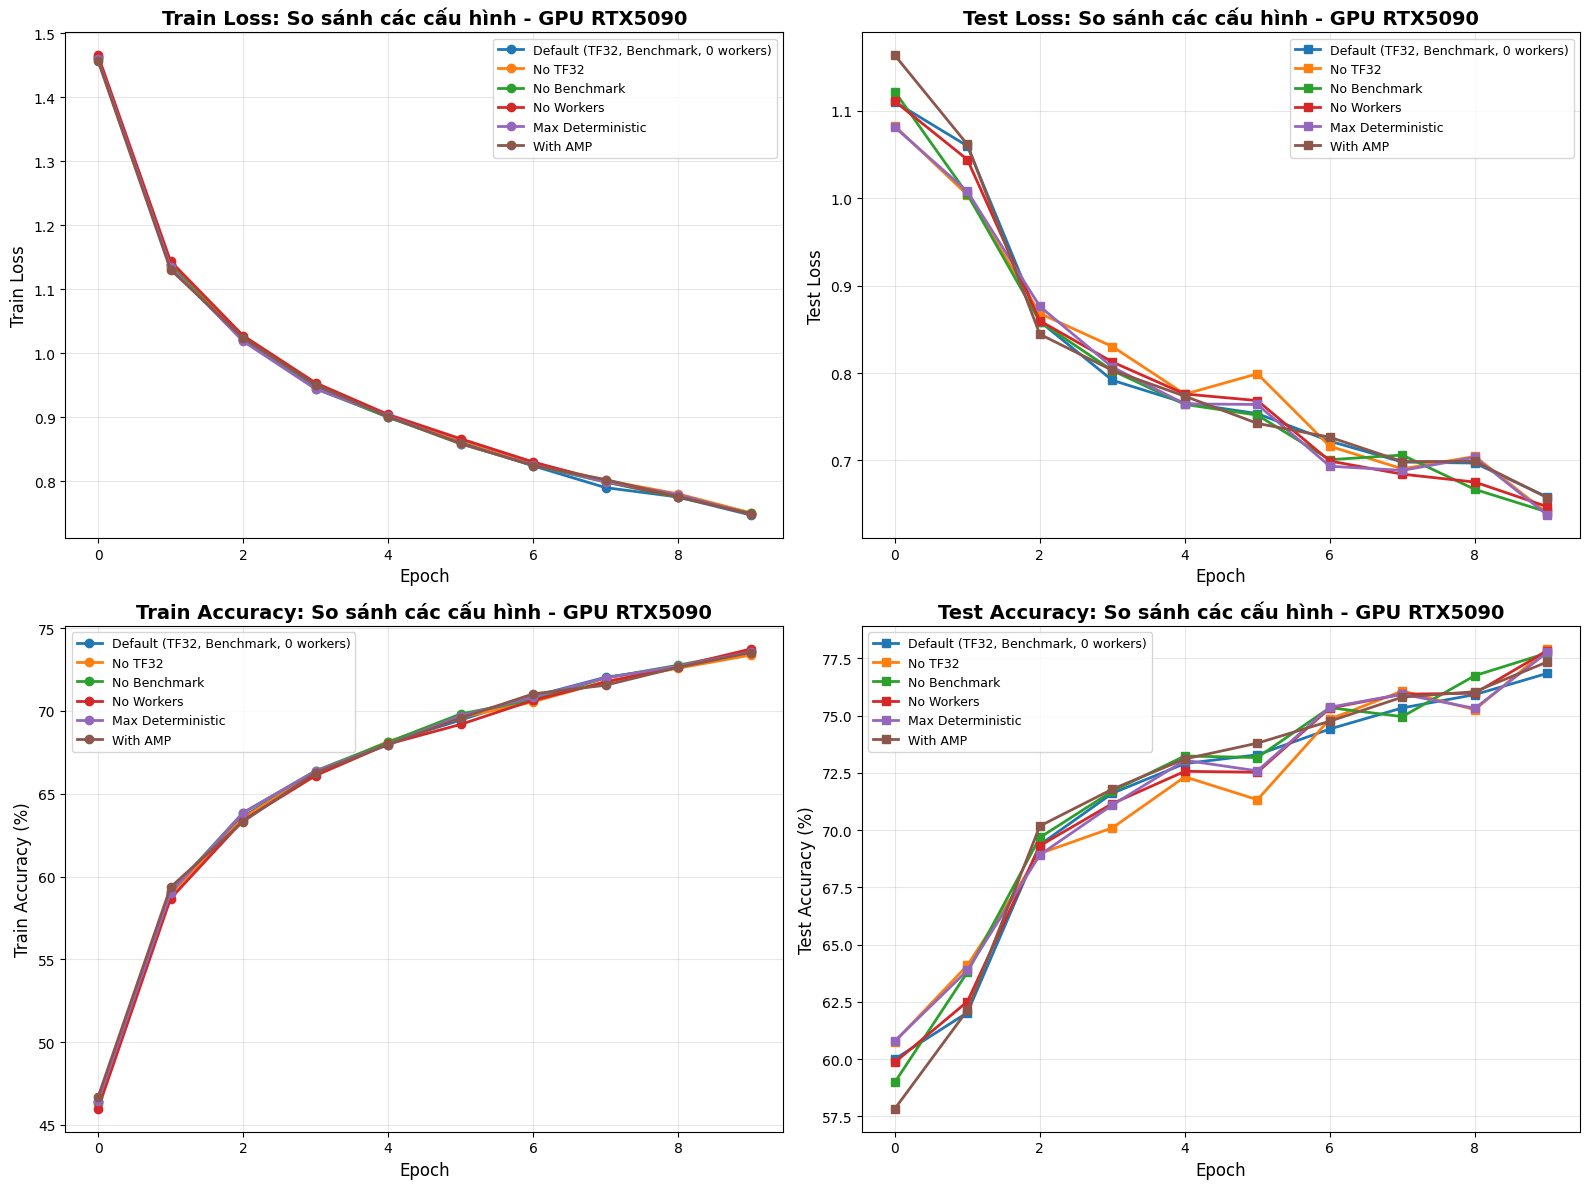


BẢNG SO SÁNH TẤT CẢ CẤU HÌNH - GPU RTX5090
Cấu hình                                           Train Loss   Test Loss    Test Acc    
----------------------------------------------------------------------------------------------------
Default (TF32, Benchmark, 0 workers)               0.7472       0.6581       76.85       %
No TF32                                            0.7507       0.6396       77.91       %
No Benchmark                                       0.7500       0.6410       77.74       %
No Workers                                         0.7487       0.6471       77.84       %
Max Deterministic                                  0.7484       0.6376       77.77       %
With AMP                                           0.7489       0.6574       77.35       %

PHÂN TÍCH ĐỘ LỆCH (so với cấu hình tối đa deterministic)
Cấu hình                                           Test Acc     Độ lệch     
------------------------------------------------------------------------------------

In [20]:
def compare_all_configs(histories, labels):
    """So sánh tất cả các cấu hình"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Train Loss
    ax = axes[0, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_loss'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Train Loss', fontsize=12)
    ax.set_title('Train Loss: So sánh các cấu hình - GPU RTX5090', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Test Loss
    ax = axes[0, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_loss'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Test Loss', fontsize=12)
    ax.set_title('Test Loss: So sánh các cấu hình - GPU RTX5090', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Train Accuracy
    ax = axes[1, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_acc'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Train Accuracy (%)', fontsize=12)
    ax.set_title('Train Accuracy: So sánh các cấu hình - GPU RTX5090', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Test Accuracy
    ax = axes[1, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_acc'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('Test Accuracy: So sánh các cấu hình - GPU RTX5090', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/deterministic_configs_comparison_RTX5090.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Bảng so sánh
    print("\n" + "="*100)
    print("BẢNG SO SÁNH TẤT CẢ CẤU HÌNH - GPU RTX5090")
    print("="*100)
    print(f"{'Cấu hình':<50} {'Train Loss':<12} {'Test Loss':<12} {'Test Acc':<12}")
    print("-"*100)
    for hist, label in zip(histories, labels):
        final_train_loss = hist['train_loss'][-1]
        final_test_loss = hist['test_loss'][-1]
        final_test_acc = hist['test_acc'][-1]
        print(f"{label:<50} {final_train_loss:<12.4f} {final_test_loss:<12.4f} {final_test_acc:<12.2f}%")
    print("="*100)
    
    # Phân tích độ lệch
    print("\n" + "="*100)
    print("PHÂN TÍCH ĐỘ LỆCH (so với cấu hình tối đa deterministic)")
    print("="*100)
    if len(histories) > 0:
        baseline = histories[-2]  # Max deterministic (trước AMP)
        baseline_test_acc = baseline['test_acc'][-1]
        
        print(f"{'Cấu hình':<50} {'Test Acc':<12} {'Độ lệch':<12}")
        print("-"*100)
        for hist, label in zip(histories, labels):
            test_acc = hist['test_acc'][-1]
            diff = test_acc - baseline_test_acc
            print(f"{label:<50} {test_acc:<12.2f}% {diff:+.2f}%")
    print("="*100)

# So sánh
if 'history_default' in globals() and 'history_no_tf32' in globals() and 'history_no_benchmark' in globals() and 'history_no_workers' in globals() and 'history_max_deterministic' in globals():
    all_histories = [
        history_default,
        history_no_tf32,
        history_no_benchmark,
        history_no_workers,
        history_max_deterministic
    ]
    
    all_labels = [
        "Default (TF32, Benchmark, 0 workers)",
        "No TF32",
        "No Benchmark",
        "No Workers",
        "Max Deterministic"
    ]
    
    # Thêm AMP nếu có
    if 'history_amp' in globals() and history_amp is not None:
        all_histories.append(history_amp)
        all_labels.append("With AMP")
    
    compare_all_configs(all_histories, all_labels)


## 6. Kết luận cho GPU NVIDIA GeForce RTX 5090

**Đặc điểm GPU NVIDIA GeForce RTX 5090**:
- Compute Capability: 12.0 (Blackwell architecture)
- ✅ Hỗ trợ TF32 (Blackwell architecture)
- ✅ Hỗ trợ FP32 và FP16 (với AMP)

**Quan sát từ các test trên RTX5090**:

1. **TF32**: RTX5090 hỗ trợ TF32, có thể bật/tắt để so sánh
2. **cuDNN Benchmark**: Tắt benchmark giúp deterministic hơn nhưng có thể chậm hơn
3. **num_workers**: Đặt = 0 loại bỏ non-determinism từ DataLoader
4. **Deterministic Algorithms**: Giúp reproducibility tốt nhất nhưng có thể chậm và không hỗ trợ tất cả operations
5. **AMP**: Mixed precision có thể gây khác biệt về kết quả do precision thấp hơn

**Khuyến nghị cho RTX5090**:
- Để reproducibility tốt nhất: Tắt TF32, tắt benchmark, num_workers=0, bật deterministic algorithms
- Để performance tốt nhất: Bật TF32, bật benchmark, nhiều workers
- Cân bằng: Tắt TF32, tắt benchmark, num_workers=0 (chấp nhận chậm hơn một chút)

**Kết quả**:
- Kết quả đã được lưu vào thư mục `results/` với tên GPU NVIDIA GeForce RTX 5090
- File JSON có thể được dùng để so sánh với các GPU khác trong notebook `04_analyze_cross_gpu_results.ipynb`

**Bước tiếp theo**:
1. Chạy các notebook tương tự trên GPU khác (T4, L4, A100, RTX 3060, TPU)
2. Copy tất cả file JSON vào cùng thư mục `results/`
3. Chạy notebook `04_analyze_cross_gpu_results.ipynb` để so sánh
